In [1]:
import numpy as np
from scipy.integrate import odeint
from typing import Dict, Optional


def synthesize_periodic(n: int, freq: float = 1.0, dt: float = 0.01) -> np.ndarray:
    """Pure periodic: single sinusoid."""
    t = np.arange(n) * dt
    return np.sin(2 * np.pi * freq * t)


def synthesize_quasi_periodic(n: int, dt: float = 0.01) -> np.ndarray:
    """Quasi-periodic: sum of incommensurate frequencies (e.g. sqrt(2), sqrt(3))."""
    t = np.arange(n) * dt
    return np.sin(2 * np.pi * np.sqrt(2) * t) + 0.5 * np.sin(2 * np.pi * np.sqrt(3) * t)


def lorenz(state: np.ndarray, t: float, sigma: float, rho: float, beta: float) -> np.ndarray:
    """Lorenz system derivatives."""
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])


def synthesize_chaotic_lorenz_x(n: int, dt: float = 0.01, sigma: float = 10.0,
                                rho: float = 28.0, beta: float = 8/3) -> np.ndarray:
    """Chaotic: x(t) from Lorenz system."""
    t = np.linspace(0, (n - 1) * dt, n)
    state0 = [1.0, 1.0, 1.0]
    sol = odeint(lorenz, state0, t, args=(sigma, rho, beta))
    return sol[:, 0]  # x(t)


def synthesize_noise(n: int, scale: float = 1.0, seed: Optional[int] = None) -> np.ndarray:
    """White Gaussian noise."""
    rng = np.random.default_rng(seed)
    return rng.standard_normal(n) * scale


def delay_embed(x: np.ndarray, m: int, tau: int) -> np.ndarray:
    """Build delay embedding: rows are [x(t), x(t-tau), ..., x(t-(m-1)*tau)]."""
    n = len(x)
    L = n - (m - 1) * tau
    if L <= 0:
        raise ValueError("Series too short for m and tau: need n > (m-1)*tau")
    rows = [x[i: i + L] for i in range(0, m * tau, tau)]
    return np.column_stack(rows)


def build_embeddings(
    n: int = 2000,
    m: int = 3,
    tau: int = 10,
    dt: float = 0.01,
    noise_scale: float = 1.0,
    seed: Optional[int] = 42,
) -> Dict[str, np.ndarray]:
    """
    Synthesize 4 canonical time series and return delay embeddings.

    Parameters
    ----------
    n : int
        Length of each time series.
    m : int
        Embedding dimension.
    tau : int
        Delay (in samples).
    dt : float
        Time step for synthetic series.
    noise_scale : float
        Scale of white noise.
    seed : int, optional
        Random seed for noise (and Lorenz if desired).

    Returns
    -------
    dict
        Keys: 'periodic', 'quasi_periodic', 'chaotic', 'noise'.
        Values: 2D arrays of shape (L, m) with L = n - (m-1)*tau.
    """
    periodic = synthesize_periodic(n, dt=dt)
    quasi_periodic = synthesize_quasi_periodic(n, dt=dt)
    chaotic = synthesize_chaotic_lorenz_x(n, dt=dt)
    noise = synthesize_noise(n, scale=noise_scale, seed=seed)

    embeddings = {
        "periodic": delay_embed(periodic, m, tau),
        "quasi_periodic": delay_embed(quasi_periodic, m, tau),
        "chaotic": delay_embed(chaotic, m, tau),
        "noise": delay_embed(noise, m, tau),
    }
    return embeddings


# Example: user-definable m and tau
m, tau = 3, 10
embeddings = build_embeddings(n=2000, m=m, tau=tau)
for name, emb in embeddings.items():
    print(f"{name}: shape {emb.shape}")

periodic: shape (1980, 3)
quasi_periodic: shape (1980, 3)
chaotic: shape (1980, 3)
noise: shape (1980, 3)


In [38]:
import numpy as np
from ripser import ripser
from persim import PersistenceImager
import matplotlib.pyplot as plt

def compute_ph_features(X_embedded):
    diagrams = ripser(X_embedded)['dgms']
    # Persistence imager
    pimgr = PersistenceImager(pixel_size=0.01)
    pimgr.fit(diagrams[1])  # fit to H1
    img = pimgr.transform(diagrams[1])

    return diagrams, img


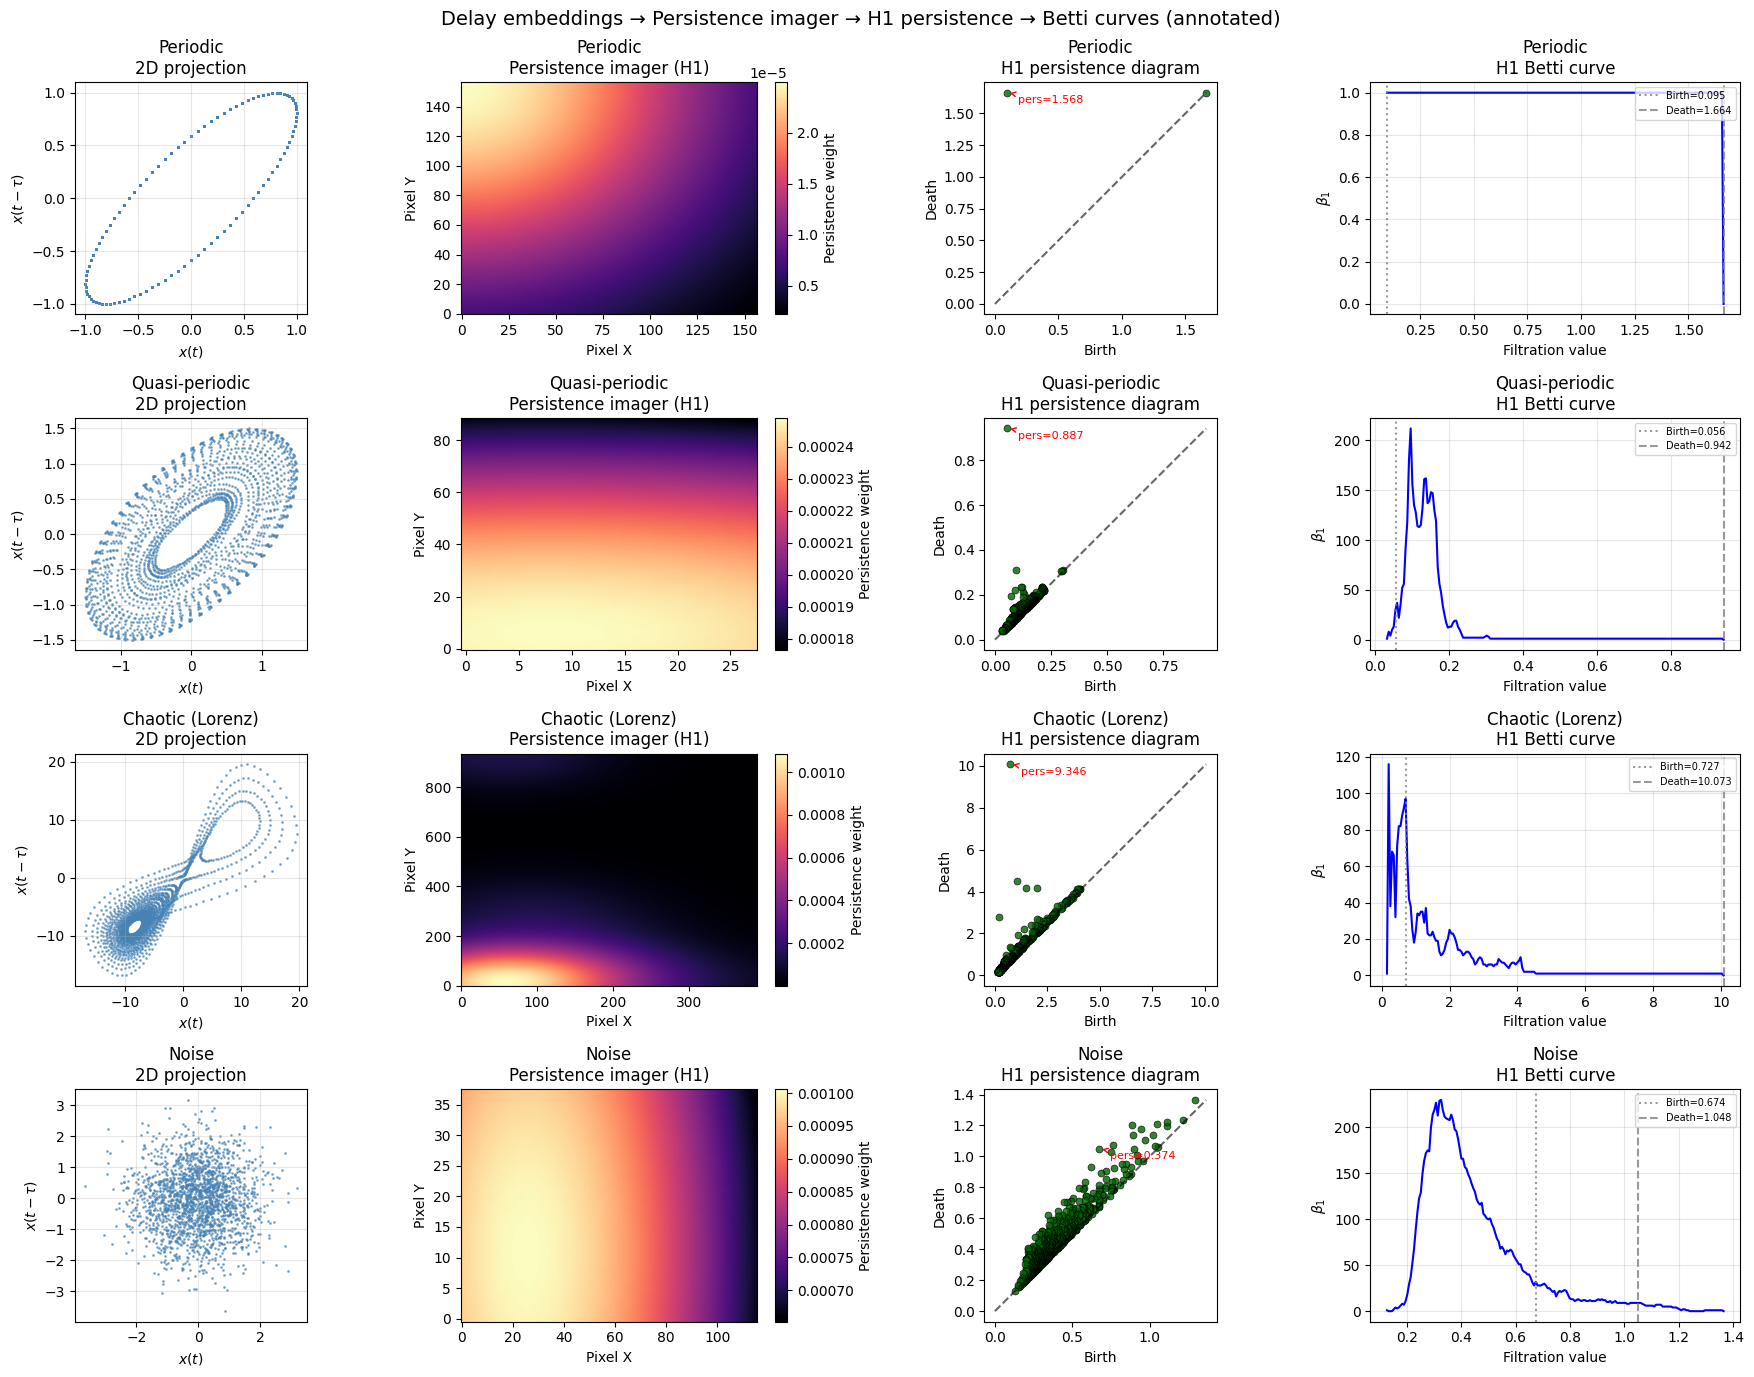

In [39]:
from persim import PersistenceImager

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
system_order = ["periodic", "quasi_periodic", "chaotic", "noise"]
titles = ["Periodic", "Quasi-periodic", "Chaotic (Lorenz)", "Noise"]

def betti_curve_h1(dgm1, n_pts=200):
    """H1 Betti curve: count of bars alive at each filtration value."""
    if len(dgm1) == 0:
        return np.array([]), np.array([])
    f_min, f_max = dgm1[:, 0].min(), dgm1[:, 1].max()
    fs = np.linspace(f_min, f_max, n_pts)
    betti = np.array([np.sum((dgm1[:, 0] <= f) & (dgm1[:, 1] > f)) for f in fs])
    return fs, betti

for row, (key, title) in enumerate(zip(system_order, titles)):
    X = embeddings[key]

    # (1) 2D projection
    ax_proj = axes[row, 0]
    ax_proj.scatter(X[:, 0], X[:, 1], s=1, alpha=0.6, c="steelblue")
    ax_proj.set_xlabel("$x(t)$")
    ax_proj.set_ylabel("$x(t-\\tau)$")
    ax_proj.set_title(f"{title}\n2D projection")
    ax_proj.set_aspect("equal")
    ax_proj.grid(True, alpha=0.3)

    # Compute PH
    result = ripser(X, maxdim=1)
    dgms = result["dgms"]
    dgm_h1 = dgms[1]
    dgm_h1 = dgm_h1[np.isfinite(dgm_h1[:, 1])] if len(dgm_h1) else np.zeros((0, 2))

    # (2) Persistence imager (H1)
    ax_imager = axes[row, 1]
    if len(dgm_h1) > 0:
        pimgr = PersistenceImager(pixel_size=0.01)
        pimgr.fit(dgm_h1)
        img = pimgr.transform(dgm_h1)
        im = ax_imager.imshow(img.T, origin="lower", aspect="auto", cmap="magma")
        plt.colorbar(im, ax=ax_imager, label="Persistence weight")
    else:
        ax_imager.imshow(np.zeros((2, 2)), origin="lower", aspect="auto", cmap="magma")
    ax_imager.set_xlabel("Pixel X")
    ax_imager.set_ylabel("Pixel Y")
    ax_imager.set_title(f"{title}\nPersistence imager (H1)")

    # (3) H1 persistence diagram
    ax_dgm = axes[row, 2]
    if len(dgm_h1) > 0:
        birth, death = dgm_h1[:, 0], dgm_h1[:, 1]
        ax_dgm.scatter(birth, death, s=25, alpha=0.8, c="darkgreen", edgecolors="black", linewidths=0.5)
        d_max = max(birth.max(), death.max())
        ax_dgm.plot([0, d_max], [0, d_max], "k--", alpha=0.6)
        pers = death - birth
        idx_top = np.argmax(pers)
        b_top, d_top = birth[idx_top], death[idx_top]
        ax_dgm.annotate(
            f"pers={d_top - b_top:.3f}",
            xy=(b_top, d_top),
            xytext=(b_top + 0.05 * d_max, d_top - 0.05 * d_max),
            fontsize=8,
            arrowprops=dict(arrowstyle="->", color="red", lw=1),
            color="red",
        )
    else:
        birth = death = np.array([])
        b_top = d_top = 0
        d_max = 1

    ax_dgm.set_xlabel("Birth")
    ax_dgm.set_ylabel("Death")
    ax_dgm.set_title(f"{title}\nH1 persistence diagram")
    ax_dgm.set_aspect("equal")

    # (4) H1 Betti curve
    ax_betti = axes[row, 3]
    if len(dgm_h1) > 0:
        fs, bc = betti_curve_h1(dgm_h1)
        ax_betti.plot(fs, bc, "b-", lw=1.5)
        ax_betti.axvline(b_top, color="gray", ls=":", alpha=0.8, label=f"Birth={b_top:.3f}")
        ax_betti.axvline(d_top, color="gray", ls="--", alpha=0.8, label=f"Death={d_top:.3f}")
        ax_betti.legend(loc="upper right", fontsize=7)
    else:
        ax_betti.plot([0, 1], [0, 0], lw=1.5, color="b")  # empty placeholder

    ax_betti.set_xlabel("Filtration value")
    ax_betti.set_ylabel("$\\beta_1$")
    ax_betti.set_title(f"{title}\nH1 Betti curve")
    ax_betti.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("Delay embeddings → Persistence imager → H1 persistence → Betti curves (annotated)", fontsize=14)
plt.show()

## Wasserstein Distances (maybe can embed in a space)

In [37]:
from persim import wasserstein
import pandas as pd
import seaborn as sns

# Collect H1 diagrams for each system
h1_diagrams = {}
for key in system_order:
    X = embeddings[key]
    result = ripser(X, maxdim=1)
    dgm_h1 = result['dgms'][1]
    dgm_h1 = dgm_h1[np.isfinite(dgm_h1[:,1])] if len(dgm_h1) else np.zeros((0,2))
    h1_diagrams[key] = dgm_h1

# Compute pairwise Wasserstein distances
dist_matrix = pd.DataFrame(index=system_order, columns=system_order, dtype=float)
for i, key1 in enumerate(system_order):
    for j, key2 in enumerate(system_order):
        dgm1, dgm2 = h1_diagrams[key1], h1_diagrams[key2]
        if len(dgm1)==0 or len(dgm2)==0:
            dist = np.nan  # handle empty diagrams
        else:
            dist = wasserstein(dgm1, dgm2)
        dist_matrix.loc[key1,key2] = dist

print("Pairwise H1 Wasserstein distances:")
print(dist_matrix)

Pairwise H1 Wasserstein distances:
                 periodic  quasi_periodic    chaotic      noise
periodic         0.000000       11.362365  71.959149  45.593507
quasi_periodic  11.362365        0.000000  81.558984  54.822781
chaotic         71.959149       81.558984   0.000000  71.667056
noise           45.593507       54.822781  71.667056   0.000000
